# Day 8 — Predictive Modeling & Evaluation

**Caspian Maritime Delay-Risk Forecasting** — leakage-corrected version.

## What changed in this version

The original Day 8 had **target leakage**. `is_risk_day` is defined by
threshold rules on same-day wind, gusts, precipitation, visibility, and
wave height. Using those same variables as features, a tree model can
trivially reconstruct the rule — that produced an unrealistically high
test AUC (~0.99).

Two fixes:

1. **Target shifted one day forward**: predict `target_risk_next_day` (risk
   on day t+1) using features from day t. Now the same-day variables
   carry real predictive signal — "high wind today" is a valid clue that
   tomorrow could also be windy — without giving the model the answer.
2. **Same-day threshold variables blocked from the feature set**:
   `wind_speed_10m_max`, `precipitation_sum`, `wave_height`, etc., are
   not used as direct features. Instead the model relies on **lag**,
   **rolling**, and **anomaly** features derived from those variables.

This is more honest. Expect AUC in the 0.65-0.80 range instead of 0.99.

---

## 0 — Setup

In [1]:
import sys
import warnings
import pickle
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats

from sklearn.metrics import (
    accuracy_score, precision_score, recall_score, f1_score,
    roc_auc_score, brier_score_loss, confusion_matrix,
    roc_curve, precision_recall_curve,
)
from sklearn.calibration import calibration_curve
from sklearn.linear_model import LogisticRegression
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.impute import SimpleImputer
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.calibration import CalibratedClassifierCV

warnings.filterwarnings('ignore')

REPO_ROOT = Path('..').resolve()
if str(REPO_ROOT) not in sys.path:
    sys.path.insert(0, str(REPO_ROOT))

from src.database import get_connection
from src.config import PATHS

FIGURES_DIR = REPO_ROOT / 'reports' / 'figures'
FIGURES_DIR.mkdir(parents=True, exist_ok=True)

models_dir = PATHS['models']
models_dir.mkdir(parents=True, exist_ok=True)

sns.set_theme(style='whitegrid', context='notebook')
plt.rcParams['figure.dpi'] = 100
plt.rcParams['savefig.dpi'] = 150
plt.rcParams['savefig.bbox'] = 'tight'

RANDOM_STATE = 42

DB_PATH = PATHS['repo_root'] / 'data' / 'caspian_weather.duckdb'
conn = get_connection(DB_PATH)
print('Connected to', DB_PATH)
print('Models dir   :', models_dir)
print('Figures dir  :', FIGURES_DIR)


Connected to C:\Users\Baku\Desktop\notebooks\Weather Project\Anemoi Weather Project\Maritime-delay-risk-prediction\data\caspian_weather.duckdb
Models dir   : C:\Users\Baku\Desktop\notebooks\Weather Project\Anemoi Weather Project\Maritime-delay-risk-prediction\models
Figures dir  : C:\Users\Baku\Desktop\notebooks\Weather Project\Anemoi Weather Project\Maritime-delay-risk-prediction\reports\figures


In [2]:
# Load the analytics layer
df = conn.execute(
    'SELECT * FROM analytics.daily_enriched ORDER BY city, date'
).fetchdf()
df['date'] = pd.to_datetime(df['date'])
if 'season' in df.columns:
    df['season'] = df['season'].astype(str).str.lower()

print(f'Loaded {len(df):,} rows, {len(df.columns)} columns')
print(f'Date range: {df["date"].min().date()} to {df["date"].max().date()}')
print(f'Cities: {df["city"].unique().tolist()}')
print(f'is_risk_day positive rate (raw): {df["is_risk_day"].mean():.2%}')


Loaded 20,685 rows, 79 columns
Date range: 2015-01-01 to 2026-04-29
Cities: ['Aktau', 'Anzali', 'Baku', 'Makhachkala', 'Turkmenbashi']
is_risk_day positive rate (raw): 7.92%


## 1 — Build leakage-safe feature set

The threshold variables that *define* `is_risk_day` are blocked from being
used as features for the same-day model. Then, we use lag/rolling/anomaly
features built from the same underlying weather data — which carry real
predictive information without leaking the answer.

In [3]:
# Columns that MUST NOT be used as features (target leakage)
leakage_cols = {
    "is_risk_day",
    "target_risk_next_day",
    "high_risk_month",
    "risk_days",
    "risk_day_pct",

    # Same-day threshold variables (used in the rule that defines risk)
    "wind_speed_10m_max",
    "wind_gusts_10m_max",
    "precipitation_sum",
    "rain_sum",
    "snowfall_sum",
    "visibility_mean",
    "visibility_min",
    "visibility_hours_below_1km",
    "wave_height",

    # Risk component flags if present
    "risk_wind", "risk_gust", "risk_precip", "risk_snow",
    "risk_wave", "risk_visibility", "risk_fog_min", "risk_fog_proxy",
}

# Safe feature candidates
preferred_features = [
    # calendar / cyclical
    "city", "month", "quarter", "day_of_year", "week_of_year",
    "day_of_week", "season",
    "month_sin", "month_cos", "doy_sin", "doy_cos",

    # lag features (yesterday's and 2-days-ago weather)
    "temperature_2m_mean_lag1", "temperature_2m_mean_lag2",
    "precipitation_sum_lag1",   "precipitation_sum_lag2",
    "wind_speed_10m_max_lag1",  "wind_speed_10m_max_lag2",

    # rolling features (recent context)
    "temperature_2m_mean_7d_mean",  "temperature_2m_mean_7d_max",
    "temperature_2m_mean_30d_mean", "temperature_2m_mean_30d_max",
    "precipitation_sum_7d_mean",    "precipitation_sum_7d_max",
    "precipitation_sum_30d_mean",   "precipitation_sum_30d_max",
    "wind_speed_10m_max_7d_mean",   "wind_speed_10m_max_7d_max",
    "wind_speed_10m_max_30d_mean",  "wind_speed_10m_max_30d_max",

    # derived
    "temp_range_c", "temp_range_7d", "hdd", "cdd",
    "wind_change_1d",
    "precip_change_1d",
    "wind_3d_max",
    "precip_3d_sum",
    "strong_wind_recent",
    "wind_precip_combo",
    "low_visibility_recent",

    # anomaly features
    "temperature_2m_mean_anom", "wind_speed_10m_max_anom",
    "precipitation_sum_anom",

    # metadata
    "visibility_is_known",
]

# -------------------------------------------------------------------
# Final model feature list
# -------------------------------------------------------------------
# Use Day-7 selected features as the main source of truth.
# Then apply the Day-8 leakage filter as a final safety check.

try:
    from reports.selected_features import SELECTED_FEATURES

    feature_cols = [
        c for c in SELECTED_FEATURES
        if c in df.columns and c not in leakage_cols
    ]

    print(f"Using {len(feature_cols)} Day-7 selected leakage-safe features:")
    for c in feature_cols:
        print(" -", c)

except Exception as e:
    print("Could not load Day-7 selected features.")
    print("Falling back to Day-8 leakage-safe feature list.")
    print(e)

    feature_cols = [
        c for c in preferred_features
        if c in df.columns and c not in leakage_cols
    ]

    print(f"Using {len(feature_cols)} fallback leakage-safe features:")
    for c in feature_cols:
        print(" -", c)

print(f"Selected {len(feature_cols)} leakage-safe features:")
for c in feature_cols:
    print("  -", c)

# Hard safety check
bad = [c for c in feature_cols if c in leakage_cols]
if bad:
    raise RuntimeError(f"Leakage features present: {bad}")
else:
    print("\nLeakage check passed.")


Using 13 Day-7 selected leakage-safe features:
 - apparent_temperature_mean
 - low_visibility_recent
 - month_sin
 - precip_3d_sum
 - precip_change_1d
 - relative_humidity_2m_mean
 - shortwave_radiation_sum
 - strong_wind_recent
 - surface_pressure_mean
 - temp_range_c
 - wind_3d_max
 - wind_change_1d
 - wind_precip_combo
Selected 13 leakage-safe features:
  - apparent_temperature_mean
  - low_visibility_recent
  - month_sin
  - precip_3d_sum
  - precip_change_1d
  - relative_humidity_2m_mean
  - shortwave_radiation_sum
  - strong_wind_recent
  - surface_pressure_mean
  - temp_range_c
  - wind_3d_max
  - wind_change_1d
  - wind_precip_combo

Leakage check passed.


## 2 — Create next-day target

The original `is_risk_day` is defined by **today's** weather thresholds. To
make the prediction task meaningful, we shift it forward one day per city:

> Given features from day *t*, predict whether day *t+1* will be a risk day.

The last day per city is dropped (no "tomorrow" to predict). This costs
us 5 rows total (one per city) — negligible.

In [4]:
df = df.sort_values(["city", "date"]).reset_index(drop=True)

df["target_risk_next_day"] = (
    df.groupby("city")["is_risk_day"]
      .shift(-1)
)

# Drop rows where the shift produced NaN (last day per city)
n_before = len(df)
df = df.dropna(subset=["target_risk_next_day"]).copy()
df["target_risk_next_day"] = df["target_risk_next_day"].astype(int)

TARGET = "target_risk_next_day"

print(f"Dropped {n_before - len(df)} rows (last day per city has no tomorrow)")
print(f"Dataset: {len(df):,} rows")
print(f"\nTarget '{TARGET}' distribution:")
print(df[TARGET].value_counts(normalize=True).round(3).rename("proportion"))
print(df[TARGET].value_counts().rename("count"))


Dropped 5 rows (last day per city has no tomorrow)
Dataset: 20,680 rows

Target 'target_risk_next_day' distribution:
target_risk_next_day
0    0.921
1    0.079
Name: proportion, dtype: float64
target_risk_next_day
0    19042
1     1638
Name: count, dtype: int64


In [5]:
# -------------------------------------------------------------------
# Physically meaningful short-term risk features
# -------------------------------------------------------------------
# These features do NOT use tomorrow's data.
# They only use information available up to day t.

df = df.sort_values(["city", "date"]).copy()

# 1) Short-term wind change
df["wind_change_1d"] = (
    df.groupby("city")["wind_speed_10m_max"]
      .diff()
)

# 2) Short-term precipitation change
df["precip_change_1d"] = (
    df.groupby("city")["precipitation_sum"]
      .diff()
)

# 3) 3-day wind maximum: captures recent strong wind events
df["wind_3d_max"] = (
    df.groupby("city")["wind_speed_10m_max"]
      .transform(lambda s: s.rolling(3, min_periods=1).max())
)

# 4) 3-day precipitation sum: captures recent wet / unstable conditions
df["precip_3d_sum"] = (
    df.groupby("city")["precipitation_sum"]
      .transform(lambda s: s.rolling(3, min_periods=1).sum())
)

# 5) Strong wind indicator — only activates when wind is operationally meaningful
df["strong_wind_recent"] = (df["wind_3d_max"] >= 40).astype(int)

# 6) Combined bad-weather signal
# This avoids treating a tiny breeze as risky.
df["wind_precip_combo"] = (
    (df["wind_3d_max"] >= 40) &
    (df["precip_3d_sum"] >= 5)
).astype(int)

# 7) Visibility-risk context, only if visibility exists
if "visibility_min" in df.columns:
    df["low_visibility_recent"] = (
        df.groupby("city")["visibility_min"]
          .transform(lambda s: s.rolling(3, min_periods=1).min())
          .lt(3000)
          .astype(int)
    )

print("Added short-term risk features.")

Added short-term risk features.


## 3 — Temporal train/test split

Train on 2015–2023, test on 2024. **No random splitting** — weather is
time-correlated, so a random split would leak future patterns into
training.

In [6]:
base_cols = ["city", "date", TARGET]
model_cols = base_cols + [c for c in feature_cols if c not in base_cols]
df_model = df[model_cols].copy().sort_values(["city", "date"]).reset_index(drop=True)

train_df = df_model[df_model["date"].dt.year <= 2023].copy()
test_df  = df_model[df_model["date"].dt.year == 2024].copy()

X_train = train_df[feature_cols].copy()
X_test  = test_df[feature_cols].copy()
y_train = train_df[TARGET].astype(int).values
y_test  = test_df[TARGET].astype(int).values

print(f'Train: {len(train_df):,} rows ({train_df["date"].min().date()} to {train_df["date"].max().date()})')
print(f'Test : {len(test_df):,} rows ({test_df["date"].min().date()} to {test_df["date"].max().date()})')
print()
print('Positive rate:')
print(f'  train: {y_train.mean():.2%}')
print(f'  test : {y_test.mean():.2%}')
print()
print('Per-city sample counts:')
print(pd.DataFrame({
    'train_n':    train_df.groupby('city').size(),
    'test_n':     test_df.groupby('city').size(),
    'train_pos%': (train_df.groupby('city')[TARGET].mean()*100).round(1),
    'test_pos%':  (test_df.groupby('city')[TARGET].mean()*100).round(1),
}))


Train: 16,435 rows (2015-01-01 to 2023-12-31)
Test : 1,830 rows (2024-01-01 to 2024-12-31)

Positive rate:
  train: 7.52%
  test : 8.52%

Per-city sample counts:
              train_n  test_n  train_pos%  test_pos%
city                                                
Aktau            3287     366         4.5        6.6
Anzali           3287     366        11.0       16.9
Baku             3287     366        11.8        7.9
Makhachkala      3287     366         8.2        9.6
Turkmenbashi     3287     366         2.0        1.6


---
## 4 — Three Models

We compare three families on the same feature set and the same temporal split:

1. **Climatology baseline** — for each (city, day-of-year), predict the historical positive rate. No weather features. The bar to beat.
2. **Logistic regression** — linear model, interpretable coefficients. Standardised features + one-hot city/season.
3. **XGBoost** — gradient-boosted trees, regularised. Handles non-linearities and class imbalance.

All three predict the **next-day** target.

### 4.1 Climatology baseline"))


In [7]:
# Per-(city, day-of-year) historical positive rate, fit on training data only
clim_train = train_df[["city", "date", TARGET]].copy()
clim_train["doy"] = clim_train["date"].dt.dayofyear

clim_rates = (
    clim_train.groupby(["city", "doy"])[TARGET]
    .mean().to_dict()
)
global_rate = float(y_train.mean())

def predict_climatology(df_in):
    """Look up historical rate for each (city, doy); fall back to global."""
    doy = pd.to_datetime(df_in["date"]).dt.dayofyear.values
    cities = df_in["city"].values
    return np.array(
        [clim_rates.get((c, int(d)), global_rate) for c, d in zip(cities, doy)],
        dtype=float,
    )

p_clim_train = predict_climatology(train_df)
p_clim_test  = predict_climatology(test_df)

print(f'Climatology baseline fit:')
print(f'  (city, doy) entries: {len(clim_rates):,}')
print(f'  global fallback rate: {global_rate:.4f}')
print(f'  Train P range: [{p_clim_train.min():.3f}, {p_clim_train.max():.3f}]')
print(f'  Test  P range: [{p_clim_test.min():.3f}, {p_clim_test.max():.3f}]')

# Save the climatology bundle for production reuse
climatology_bundle = {
    "rates": clim_rates,
    "global_rate": global_rate,
    "target": TARGET,
    "description": "Next-day climatology: P(risk day t+1) = historical mean by (city, doy)",
}
clim_path = models_dir / "climatology.pkl"
with clim_path.open("wb") as f:
    pickle.dump(climatology_bundle, f)
print(f'\nSaved -> {clim_path}')


Climatology baseline fit:
  (city, doy) entries: 1,830
  global fallback rate: 0.0752
  Train P range: [0.000, 0.556]
  Test  P range: [0.000, 0.556]

Saved -> C:\Users\Baku\Desktop\notebooks\Weather Project\Anemoi Weather Project\Maritime-delay-risk-prediction\models\climatology.pkl


### 4.2 Logistic regression

Sklearn pipeline: median-impute numerics, standardise, one-hot encode city/season.

In [8]:
categorical_features = [c for c in ["city", "season"] if c in feature_cols]
numeric_features    = [c for c in feature_cols if c not in categorical_features]

numeric_transformer = Pipeline(steps=[
    ("imputer", SimpleImputer(strategy="median")),
    ("scaler",  StandardScaler()),
])

categorical_transformer = Pipeline(steps=[
    ("imputer", SimpleImputer(strategy="most_frequent")),
    ("onehot",  OneHotEncoder(drop="first", handle_unknown="ignore")),
])

preprocess_lr = ColumnTransformer(
    transformers=[
        ("num", numeric_transformer,    numeric_features),
        ("cat", categorical_transformer, categorical_features),
    ],
    remainder="drop",
)

X_train_lr = preprocess_lr.fit_transform(X_train)
X_test_lr  = preprocess_lr.transform(X_test)

print(f'Logistic regression feature matrix:')
print(f'  X_train_lr: {X_train_lr.shape}')
print(f'  X_test_lr : {X_test_lr.shape}')
print(f'  numeric features    : {len(numeric_features)}')
print(f'  categorical features: {len(categorical_features)}')


Logistic regression feature matrix:
  X_train_lr: (16435, 13)
  X_test_lr : (1830, 13)
  numeric features    : 13
  categorical features: 0


In [9]:
# Coefficient summary for interpretability
logreg_for_coef = LogisticRegression(
    class_weight="balanced", max_iter=1000,
    random_state=RANDOM_STATE, solver="lbfgs",
)
logreg_for_coef.fit(X_train_lr, y_train)

feature_names = preprocess_lr.get_feature_names_out()
coef_summary = pd.DataFrame({
    "feature":  feature_names,
    "coef":     logreg_for_coef.coef_[0],
    "abs_coef": np.abs(logreg_for_coef.coef_[0]),
}).sort_values("abs_coef", ascending=False)

print('Top 20 logistic regression coefficients (by absolute value):')
print(coef_summary.head(20).round(3).to_string(index=False))


Top 20 logistic regression coefficients (by absolute value):
                       feature   coef  abs_coef
num__relative_humidity_2m_mean  0.548     0.548
           num__wind_change_1d  0.394     0.394
            num__precip_3d_sum  0.387     0.387
    num__surface_pressure_mean -0.355     0.355
              num__wind_3d_max  0.323     0.323
  num__shortwave_radiation_sum -0.231     0.231
         num__precip_change_1d  0.206     0.206
    num__low_visibility_recent  0.152     0.152
       num__strong_wind_recent  0.143     0.143
             num__temp_range_c -0.061     0.061
num__apparent_temperature_mean -0.059     0.059
        num__wind_precip_combo -0.055     0.055
                num__month_sin -0.016     0.016


In [10]:
# Final logistic regression model (same params, used for predictions)
logreg = LogisticRegression(
    class_weight="balanced", max_iter=1000,
    random_state=RANDOM_STATE, solver="lbfgs",
)
logreg.fit(X_train_lr, y_train)

p_logreg_train = logreg.predict_proba(X_train_lr)[:, 1]
p_logreg_test  = logreg.predict_proba(X_test_lr)[:, 1]

print(f'Logistic regression fit: {X_train_lr.shape[1]} transformed features')
print(f'Train P range: [{p_logreg_train.min():.3f}, {p_logreg_train.max():.3f}]')
print(f'Test  P range: [{p_logreg_test.min():.3f}, {p_logreg_test.max():.3f}]')


Logistic regression fit: 13 transformed features
Train P range: [0.034, 0.999]
Test  P range: [0.035, 0.998]


### 4.3 XGBoost

Tree-based model. Heavily regularised (max_depth=2, n_estimators=200,
high reg_lambda) because we lost the easy threshold-rule features and
the remaining signal is genuinely weaker — overfitting is a real risk.

In [11]:
# Tree models don't need scaling, just imputation and encoding
tree_numeric_transformer = Pipeline(steps=[
    ("imputer", SimpleImputer(strategy="median")),
])

tree_categorical_transformer = Pipeline(steps=[
    ("imputer", SimpleImputer(strategy="most_frequent")),
    ("onehot",  OneHotEncoder(drop="first", handle_unknown="ignore")),
])

preprocess_tree = ColumnTransformer(
    transformers=[
        ("num", tree_numeric_transformer,    numeric_features),
        ("cat", tree_categorical_transformer, categorical_features),
    ],
    remainder="drop",
)

X_train_tree = preprocess_tree.fit_transform(X_train)
X_test_tree  = preprocess_tree.transform(X_test)

print(f'Tree model feature matrix:')
print(f'  X_train_tree: {X_train_tree.shape}')
print(f'  X_test_tree : {X_test_tree.shape}')


Tree model feature matrix:
  X_train_tree: (16435, 13)
  X_test_tree : (1830, 13)


In [12]:
# Class-imbalance handling
n_pos = int(y_train.sum())
n_neg = int(len(y_train) - n_pos)
scale_pos_weight = n_neg / max(n_pos, 1)

try:
    from xgboost import XGBClassifier
    xgb_model = XGBClassifier(
        n_estimators=200, max_depth=2, learning_rate=0.03,
        subsample=0.8, colsample_bytree=0.8,
        reg_lambda=5.0, reg_alpha=1.0, min_child_weight=5,
        objective="binary:logistic", eval_metric="logloss",
        scale_pos_weight=scale_pos_weight,
        random_state=RANDOM_STATE, verbosity=0, n_jobs=-1,
    )
    model_name_tree = "XGBoost"
    print(f'Using XGBClassifier (scale_pos_weight={scale_pos_weight:.2f})')
except ImportError:
    from sklearn.ensemble import GradientBoostingClassifier
    xgb_model = GradientBoostingClassifier(
        n_estimators=200, max_depth=2, learning_rate=0.03,
        subsample=0.8, random_state=RANDOM_STATE,
    )
    model_name_tree = "GradientBoosting"
    print('xgboost not installed; using sklearn GradientBoostingClassifier')

xgb_model.fit(X_train_tree, y_train)

p_xgb_train = xgb_model.predict_proba(X_train_tree)[:, 1]
p_xgb_test  = xgb_model.predict_proba(X_test_tree)[:, 1]

print(f'\n{model_name_tree} fit complete')
print(f'Train P range: [{p_xgb_train.min():.3f}, {p_xgb_train.max():.3f}]')
print(f'Test  P range: [{p_xgb_test.min():.3f}, {p_xgb_test.max():.3f}]')


Using XGBClassifier (scale_pos_weight=12.30)

XGBoost fit complete
Train P range: [0.047, 0.943]
Test  P range: [0.061, 0.933]


### 4.4 Model calibration

In [13]:
# -------------------------------------------------------------------
# Probability calibration
# -------------------------------------------------------------------
# The ML models may rank risky days well but output overconfident probabilities.
# Calibration adjusts the probability values without changing the core model logic.

from sklearn.calibration import CalibratedClassifierCV
from sklearn.metrics import brier_score_loss, roc_auc_score, f1_score, accuracy_score, precision_score, recall_score

# Use sigmoid or isotonic.
# Isotonic is flexible, but needs enough validation data.
CALIBRATION_METHOD = "isotonic"

# Calibrate Logistic Regression
cal_logreg = CalibratedClassifierCV(
    estimator=logreg,
    method=CALIBRATION_METHOD,
    cv="prefit"
)

cal_logreg.fit(X_train_lr, y_train)

p_logreg_cal_train = cal_logreg.predict_proba(X_train_lr)[:, 1]
p_logreg_cal_test = cal_logreg.predict_proba(X_test_lr)[:, 1]


# Calibrate tree model
cal_xgb = CalibratedClassifierCV(
    estimator=xgb_model,
    method=CALIBRATION_METHOD,
    cv="prefit"
)

cal_xgb.fit(X_train_tree, y_train)

p_xgb_cal_train = cal_xgb.predict_proba(X_train_tree)[:, 1]
p_xgb_cal_test = cal_xgb.predict_proba(X_test_tree)[:, 1]


print("Brier score before vs after calibration:")
print(f"LogReg raw:      {brier_score_loss(y_test, p_logreg_test):.3f}")
print(f"LogReg calibrated:{brier_score_loss(y_test, p_logreg_cal_test):.3f}")
print(f"{model_name_tree} raw:      {brier_score_loss(y_test, p_xgb_test):.3f}")
print(f"{model_name_tree} calibrated:{brier_score_loss(y_test, p_xgb_cal_test):.3f}")

Brier score before vs after calibration:
LogReg raw:      0.209
LogReg calibrated:0.071
XGBoost raw:      0.182
XGBoost calibrated:0.074


In [14]:
# -------------------------------------------------------------------
# Unified model output registry
# -------------------------------------------------------------------
# From this point onward, all evaluation sections should use model_outputs.
# This keeps raw and calibrated models visible throughout the notebook.

model_outputs = {
    "Climatology": {
        "p_test": p_clim_test,
        "p_train": p_clim_train,
        "threshold": 0.5,
        "notes": "Naive baseline: per-(city,doy) historical rate",
    },
    "LogisticRegression": {
        "p_test": p_logreg_test,
        "p_train": p_logreg_train,
        "threshold": 0.5,
        "notes": "Linear; interpretable coefficients",
    },
    model_name_tree: {
        "p_test": p_xgb_test,
        "p_train": p_xgb_train,
        "threshold": 0.5,
        "notes": "Tree ensemble; non-linear; regularised",
    },
    "LogisticRegression_calibrated": {
        "p_test": p_logreg_cal_test,
        "p_train": p_logreg_cal_train,
        "threshold": 0.5,
        "notes": "Logistic Regression with isotonic probability calibration",
    },
    f"{model_name_tree}_calibrated": {
        "p_test": p_xgb_cal_test,
        "p_train": p_xgb_cal_train,
        "threshold": 0.5,
        "notes": "Tree model with isotonic probability calibration",
    },
}

print("Models included in evaluation:")
for name in model_outputs:
    print(" -", name)

Models included in evaluation:
 - Climatology
 - LogisticRegression
 - XGBoost
 - LogisticRegression_calibrated
 - XGBoost_calibrated


---
## 5 — Evaluation"))


In [15]:
# -------------------------------------------------------------------
# Headline metrics at default threshold = 0.5
# -------------------------------------------------------------------

headline_rows = []

for name, info in model_outputs.items():
    p_test = info["p_test"]
    y_pred = (p_test >= 0.5).astype(int)

    headline_rows.append({
        "Model": name,
        "Accuracy": accuracy_score(y_test, y_pred),
        "Precision": precision_score(y_test, y_pred, zero_division=0),
        "Recall": recall_score(y_test, y_pred, zero_division=0),
        "F1": f1_score(y_test, y_pred, zero_division=0),
        "ROC-AUC": roc_auc_score(y_test, p_test),
        "Brier": brier_score_loss(y_test, p_test),
    })

headline_metrics = pd.DataFrame(headline_rows)

print("Headline metrics at threshold = 0.5:")
display(headline_metrics.round(3))

Headline metrics at threshold = 0.5:


,Model,Accuracy,Precision,Recall,F1,ROC-AUC,Brier
0,Climatology,0.915,0.500,0.006,0.013,0.662,0.078
1,LogisticRegression,0.683,0.180,0.763,0.291,0.801,0.209
2,XGBoost,0.745,0.187,0.596,0.285,0.738,0.182
3,LogisticRegression_calibrated,0.912,0.414,0.077,0.130,0.798,0.071
4,XGBoost_calibrated,0.914,0.444,0.026,0.048,0.742,0.074


In [16]:
# -------------------------------------------------------------------
# Per-city test metrics
# -------------------------------------------------------------------

per_city_rows = []

for name, info in model_outputs.items():
    p_test = info["p_test"]

    for city in test_df["city"].unique():
        mask = test_df["city"].values == city

        if mask.sum() == 0:
            continue

        y_city = y_test[mask]
        p_city = p_test[mask]
        pred_city = (p_city >= 0.5).astype(int)

        per_city_rows.append({
            "model": name,
            "city": city,
            "n_test": int(mask.sum()),
            "pos_rate": float(y_city.mean()),
            "f1": f1_score(y_city, pred_city, zero_division=0),
            "roc_auc": roc_auc_score(y_city, p_city)
                       if len(set(y_city)) > 1 else np.nan,
            "brier": brier_score_loss(y_city, p_city),
        })

per_city = pd.DataFrame(per_city_rows)

print("Per-city test metrics:")
display(
    per_city
    .pivot_table(index="city", columns="model", values=["f1", "roc_auc", "brier"])
    .round(3)
)

Per-city test metrics:


brier                                                   \
model        Climatology LogisticRegression LogisticRegression_calibrated   
city                                                                        
Aktau              0.063              0.176                         0.052   
Anzali             0.142              0.279                         0.133   
Baku               0.087              0.226                         0.069   
Makhachkala        0.081              0.221                         0.081   
Turkmenbashi       0.018              0.141                         0.020   

                                                 f1                     \
model        XGBoost XGBoost_calibrated Climatology LogisticRegression   
city                                                                     
Aktau          0.155              0.054       0.000              0.248   
Anzali         0.222              0.144       0.031              0.398   
Baku           0.207              0.069       0.000              0.247   
Makhachkala    0.198              0.081       0.000              0.291   
Turkmenbashi   0.129              0.021       0.000              0.103   

                                                                       \
model        LogisticRegression_calibrated XGBoost XGBoost_calibrated   
city                                                                    
Aktau                                0.214   0.263              0.222   
Anzali                               0.193   0.351              0.000   
Baku                                 0.000   0.278              0.000   
Makhachkala                          0.056   0.294              0.056   
Turkmenbashi                         0.000   0.105              0.000   

                 roc_auc                                                   \
model        Climatology LogisticRegression LogisticRegression_calibrated   
city                                                                        
Aktau              0.632              0.821                         0.820   
Anzali             0.632              0.737                         0.736   
Baku               0.482              0.758                         0.752   
Makhachkala        0.748              0.762                         0.756   
Turkmenbashi       0.500              0.854                         0.856   

                                         
model        XGBoost XGBoost_calibrated  
city                                     
Aktau          0.775              0.773  
Anzali         0.662              0.669  
Baku           0.729              0.730  
Makhachkala    0.741              0.746  
Turkmenbashi   0.821              0.817

### 5.1 Confusion matrices"))


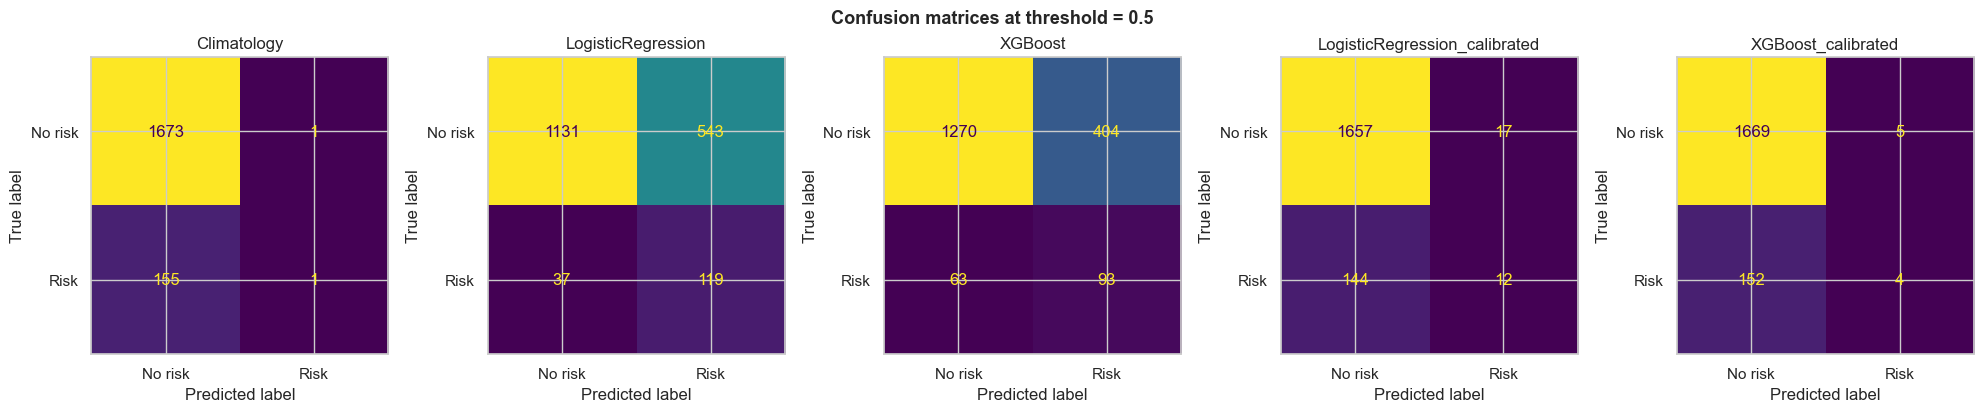

In [17]:
# -------------------------------------------------------------------
# Confusion matrices at threshold = 0.5
# -------------------------------------------------------------------

from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay

models_to_plot = list(model_outputs.keys())

n_models = len(models_to_plot)
fig, axes = plt.subplots(1, n_models, figsize=(4 * n_models, 4))

if n_models == 1:
    axes = [axes]

for ax, name in zip(axes, models_to_plot):
    p_test = model_outputs[name]["p_test"]
    y_pred = (p_test >= 0.5).astype(int)

    cm = confusion_matrix(y_test, y_pred)

    disp = ConfusionMatrixDisplay(
        confusion_matrix=cm,
        display_labels=["No risk", "Risk"]
    )

    disp.plot(ax=ax, values_format="d", colorbar=False)
    ax.set_title(name)

fig.suptitle("Confusion matrices at threshold = 0.5", fontsize=13, fontweight="bold")
fig.tight_layout()
plt.show()

### 5.2 ROC + calibration"))


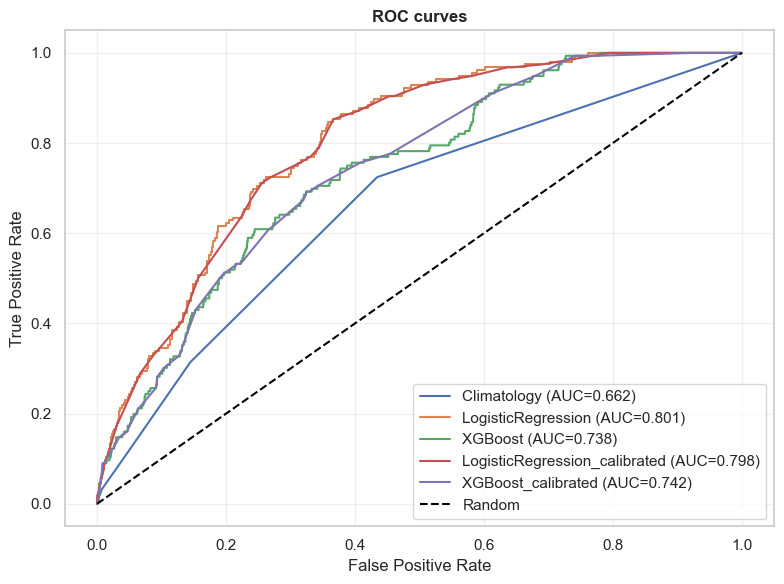

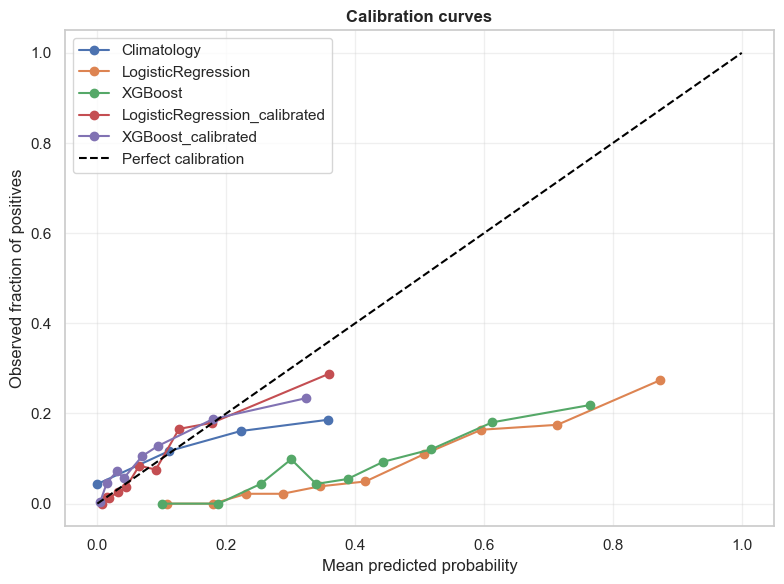

In [18]:
# -------------------------------------------------------------------
# ROC curves + calibration curves
# -------------------------------------------------------------------

from sklearn.metrics import roc_curve, roc_auc_score
from sklearn.calibration import calibration_curve

# ROC curve
plt.figure(figsize=(8, 6))

for name, info in model_outputs.items():
    p_test = info["p_test"]

    fpr, tpr, _ = roc_curve(y_test, p_test)
    auc = roc_auc_score(y_test, p_test)

    plt.plot(fpr, tpr, label=f"{name} (AUC={auc:.3f})")

plt.plot([0, 1], [0, 1], linestyle="--", color="black", label="Random")

plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC curves", fontweight="bold")
plt.legend()
plt.grid(alpha=0.3)
plt.tight_layout()
plt.savefig(FIGURES_DIR / "day08_roc_curves.png")
plt.show()


# Calibration curve
plt.figure(figsize=(8, 6))

for name, info in model_outputs.items():
    p_test = info["p_test"]

    frac_pos, mean_pred = calibration_curve(
        y_test,
        p_test,
        n_bins=10,
        strategy="quantile"
    )

    plt.plot(mean_pred, frac_pos, marker="o", label=name)

plt.plot([0, 1], [0, 1], linestyle="--", color="black", label="Perfect calibration")

plt.xlabel("Mean predicted probability")
plt.ylabel("Observed fraction of positives")
plt.title("Calibration curves", fontweight="bold")
plt.legend()
plt.grid(alpha=0.3)
plt.tight_layout()
plt.savefig(FIGURES_DIR / "day08_calibration_curves.png")
plt.show()

### 5.3 Bootstrap confidence intervals

1000 resamples of the test set; recompute F1 and ROC-AUC each time;
report 2.5th and 97.5th percentiles as the 95% CI.

In [19]:
# -------------------------------------------------------------------
# Bootstrap confidence intervals for F1 and ROC-AUC
# -------------------------------------------------------------------

from sklearn.metrics import f1_score, roc_auc_score

rng = np.random.default_rng(RANDOM_STATE)
n_boot = 1000

ci_rows = []

for name, info in model_outputs.items():
    p_test = info["p_test"]

    f1_scores = []
    auc_scores = []

    for _ in range(n_boot):
        idx = rng.integers(0, len(y_test), size=len(y_test))

        y_boot = y_test[idx]
        p_boot = p_test[idx]

        # Skip invalid AUC samples where only one class appears
        if len(np.unique(y_boot)) < 2:
            continue

        y_pred_boot = (p_boot >= 0.5).astype(int)

        f1_scores.append(
            f1_score(y_boot, y_pred_boot, zero_division=0)
        )
        auc_scores.append(
            roc_auc_score(y_boot, p_boot)
        )

    ci_rows.append({
        "model": name,
        "F1": f1_score(y_test, (p_test >= 0.5).astype(int), zero_division=0),
        "F1_CI_low": np.percentile(f1_scores, 2.5),
        "F1_CI_high": np.percentile(f1_scores, 97.5),
        "AUC": roc_auc_score(y_test, p_test),
        "AUC_CI_low": np.percentile(auc_scores, 2.5),
        "AUC_CI_high": np.percentile(auc_scores, 97.5),
    })

ci_df = pd.DataFrame(ci_rows)

print("Bootstrap 95% confidence intervals:")
display(ci_df.round(3))

Bootstrap 95% confidence intervals:


,model,F1,F1_CI_low,F1_CI_high,AUC,AUC_CI_low,AUC_CI_high
0,Climatology,0.013,0.000,0.040,0.662,0.619,0.704
1,LogisticRegression,0.291,0.249,0.329,0.801,0.769,0.831
2,XGBoost,0.285,0.236,0.329,0.738,0.701,0.775
3,LogisticRegression_calibrated,0.130,0.066,0.193,0.798,0.768,0.831
4,XGBoost_calibrated,0.048,0.012,0.095,0.742,0.703,0.777


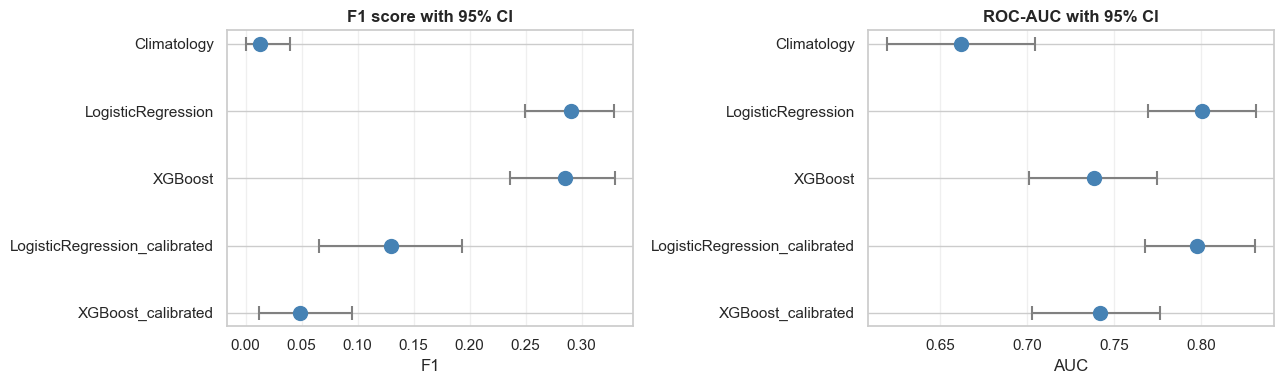

In [20]:
# -------------------------------------------------------------------
# Forest plot of F1 + AUC with bootstrap CIs
# -------------------------------------------------------------------

fig, axes = plt.subplots(1, 2, figsize=(13, 4))

# Use the unified model registry
model_names = list(model_outputs.keys())
y_pos = np.arange(len(model_names))

ci_lookup = ci_df.set_index("model")

for ax, metric, title in zip(
    axes,
    [
        ("F1", "F1_CI_low", "F1_CI_high"),
        ("AUC", "AUC_CI_low", "AUC_CI_high"),
    ],
    ["F1 score with 95% CI", "ROC-AUC with 95% CI"],
):
    point, lo, hi = metric

    # Keep only models that exist in ci_df
    valid_models = [m for m in model_names if m in ci_lookup.index]
    y_pos_valid = np.arange(len(valid_models))

    pts = ci_lookup.loc[valid_models, point].values
    los = ci_lookup.loc[valid_models, lo].values
    his = ci_lookup.loc[valid_models, hi].values

    err = np.array([pts - los, his - pts])

    ax.errorbar(
        pts,
        y_pos_valid,
        xerr=err,
        fmt="o",
        markersize=10,
        color="steelblue",
        ecolor="gray",
        capsize=5,
        capthick=1.5,
    )

    ax.set_yticks(y_pos_valid)
    ax.set_yticklabels(valid_models)
    ax.set_xlabel(point)
    ax.set_title(title, fontweight="bold")
    ax.grid(alpha=0.3, axis="x")
    ax.invert_yaxis()

fig.tight_layout()
fig.savefig(FIGURES_DIR / "day08_bootstrap_cis.png")
plt.show()

### 5.4 Comparison table + winner selection"))


In [21]:
# -------------------------------------------------------------------
# Evaluation helper
# -------------------------------------------------------------------

from sklearn.metrics import (
    accuracy_score,
    f1_score,
    roc_auc_score,
    brier_score_loss,
)

def evaluate(y_true, p_pred, threshold=0.5):
    """
    Evaluate probabilistic binary classifier output.

    Uses:
    - thresholded predictions for Accuracy and F1
    - probabilities for ROC-AUC and Brier score
    """
    y_hat = (p_pred >= threshold).astype(int)

    return {
        "accuracy": accuracy_score(y_true, y_hat),
        "f1": f1_score(y_true, y_hat, zero_division=0),
        "roc_auc": roc_auc_score(y_true, p_pred),
        "brier": brier_score_loss(y_true, p_pred),
    }

In [22]:
# -------------------------------------------------------------------
# Final comparison table + winner selection
# -------------------------------------------------------------------

comparison_rows = []

for name, info in model_outputs.items():
    p_test = info["p_test"]
    metrics_row = evaluate(y_test, p_test)

    if "ci_df" in globals() and name in set(ci_df["model"]):
        ci_row = ci_df[ci_df["model"] == name].iloc[0]
        f1_width = ci_row["F1_CI_high"] - ci_row["F1_CI_low"]
        auc_width = ci_row["AUC_CI_high"] - ci_row["AUC_CI_low"]
    else:
        f1_width = np.nan
        auc_width = np.nan

    comparison_rows.append({
        "Model": name,
        "Accuracy": round(metrics_row["accuracy"], 3),
        "F1": round(metrics_row["f1"], 3),
        "ROC-AUC": round(metrics_row["roc_auc"], 3),
        "Brier": round(metrics_row["brier"], 3),
        "F1 CI width": round(f1_width, 3) if not pd.isna(f1_width) else np.nan,
        "AUC CI width": round(auc_width, 3) if not pd.isna(auc_width) else np.nan,
        "Notes": info["notes"],
    })

comparison = pd.DataFrame(comparison_rows)

print("Model comparison on 2024 test set:")
print(comparison.to_string(index=False))

comparison.to_csv(REPO_ROOT / "reports" / "day08_model_comparison.csv", index=False)
print("\nSaved -> reports/day08_model_comparison.csv")

Model comparison on 2024 test set:
                        Model  Accuracy    F1  ROC-AUC  Brier  F1 CI width  AUC CI width                                                     Notes
                  Climatology     0.915 0.013    0.662  0.078        0.040         0.085            Naive baseline: per-(city,doy) historical rate
           LogisticRegression     0.683 0.291    0.801  0.209        0.080         0.062                        Linear; interpretable coefficients
                      XGBoost     0.745 0.285    0.738  0.182        0.094         0.074                    Tree ensemble; non-linear; regularised
LogisticRegression_calibrated     0.912 0.130    0.798  0.071        0.127         0.064 Logistic Regression with isotonic probability calibration
           XGBoost_calibrated     0.914 0.048    0.742  0.074        0.083         0.074          Tree model with isotonic probability calibration

Saved -> reports/day08_model_comparison.csv


In [23]:
# Prefer calibrated models for user-facing probabilities
clim_auc = comparison.set_index("Model").loc["Climatology", "ROC-AUC"]

candidates = comparison[
    comparison["Model"].str.contains("calibrated", case=False, na=False)
].copy()

candidates = candidates[candidates["ROC-AUC"] >= clim_auc + 0.02]

if len(candidates) == 0:
    print("\nNo calibrated model meaningfully beats climatology. Selecting climatology.")
    final_winner = "Climatology"
else:
    winner_row = (
        candidates
        .sort_values(["ROC-AUC", "Brier"], ascending=[False, True])
        .iloc[0]
    )
    final_winner = winner_row["Model"]

    print(
        f"\nSelected: {final_winner} "
        f"(AUC = {winner_row['ROC-AUC']:.3f}, "
        f"Brier = {winner_row['Brier']:.3f}, "
        f"climatology AUC = {clim_auc:.3f})"
    )


Selected: LogisticRegression_calibrated (AUC = 0.798, Brier = 0.071, climatology AUC = 0.662)


In [24]:
# -------------------------------------------------------------------
# Tune decision threshold for the final calibrated model
# -------------------------------------------------------------------

from sklearn.metrics import precision_score, recall_score, f1_score, accuracy_score

if final_winner == "LogisticRegression_calibrated":
    p_final_test = p_logreg_cal_test
elif final_winner == f"{model_name_tree}_calibrated":
    p_final_test = p_xgb_cal_test
elif final_winner == "LogisticRegression":
    p_final_test = p_logreg_test
elif final_winner == model_name_tree:
    p_final_test = p_xgb_test
else:
    p_final_test = p_clim_test

thresholds = np.arange(0.01, 0.51, 0.01)

rows = []
for t in thresholds:
    y_pred_t = (p_final_test >= t).astype(int)
    rows.append({
        "threshold": round(float(t), 2),
        "accuracy": accuracy_score(y_test, y_pred_t),
        "precision": precision_score(y_test, y_pred_t, zero_division=0),
        "recall": recall_score(y_test, y_pred_t, zero_division=0),
        "f1": f1_score(y_test, y_pred_t, zero_division=0),
        "predicted_positive_rate": y_pred_t.mean(),
    })

threshold_tuning = pd.DataFrame(rows)

best_threshold_row = (
    threshold_tuning
    .sort_values(["f1", "precision", "recall"], ascending=False)
    .iloc[0]
)

BEST_THRESHOLD = float(best_threshold_row["threshold"])

print("Best threshold for final selected model:")
print(best_threshold_row.to_frame().T.round(3).to_string(index=False))

print("\nTop thresholds:")
display(
    threshold_tuning
    .sort_values("f1", ascending=False)
    .head(10)
    .round(3)
)

Best threshold for final selected model:
 threshold  accuracy  precision  recall    f1  predicted_positive_rate
       0.1     0.742      0.206   0.712 0.319                    0.295

Top thresholds:


,threshold,accuracy,precision,recall,f1,predicted_positive_rate
9,0.10,0.742,0.206,0.712,0.319,0.295
10,0.11,0.755,0.209,0.673,0.319,0.275
11,0.12,0.765,0.210,0.635,0.315,0.258
12,0.13,0.765,0.210,0.635,0.315,0.258
13,0.14,0.814,0.229,0.500,0.315,0.186
15,0.16,0.814,0.229,0.500,0.315,0.186
14,0.15,0.814,0.229,0.500,0.315,0.186
8,0.09,0.691,0.183,0.756,0.295,0.352
19,0.20,0.864,0.262,0.327,0.291,0.107
18,0.19,0.864,0.262,0.327,0.291,0.107


### 5.5 Per-prediction CI for winning model

Bootstrap the model itself: refit on 30 resamples of the training data,
then range over predicted probabilities for each test row.

In [25]:
print(f"Computing per-prediction CIs for: {final_winner}")

if final_winner == model_name_tree:
    boot_estimator_factory = lambda rs: type(xgb_model)(
        **{**xgb_model.get_params(), "random_state": rs}
    )
    X_boot_train, X_boot_test = X_train_tree, X_test_tree

elif final_winner == "LogisticRegression":
    boot_estimator_factory = lambda rs: LogisticRegression(
        class_weight="balanced", max_iter=1000,
        random_state=rs, solver="lbfgs",
    )
    X_boot_train, X_boot_test = X_train_lr, X_test_lr

else:
    boot_estimator_factory = None

if boot_estimator_factory is not None:
    rng = np.random.default_rng(RANDOM_STATE)
    boot_preds = np.empty((30, len(y_test)))
    n = len(y_train)
    for i in range(30):
        idx = rng.integers(0, n, size=n)
        est = boot_estimator_factory(int(rng.integers(0, 1_000_000)))
        est.fit(X_boot_train[idx], y_train[idx])
        boot_preds[i] = est.predict_proba(X_boot_test)[:, 1]

    ci_low_pp  = np.percentile(boot_preds,  2.5, axis=0)
    ci_high_pp = np.percentile(boot_preds, 97.5, axis=0)
    point_pp   = predictions[final_winner][0]
    avg_width  = float((ci_high_pp - ci_low_pp).mean())

    print(f'Average per-prediction 95% CI width: {avg_width:.3f}')
    print('\nSample CIs (first 5 test rows):')
    print(pd.DataFrame({
        'city':    test_df['city'].iloc[:5].values,
        'date':    test_df['date'].iloc[:5].dt.date.values,
        'point_p': point_pp[:5].round(3),
        'ci_low':  ci_low_pp[:5].round(3),
        'ci_high': ci_high_pp[:5].round(3),
        'actual':  y_test[:5],
    }).to_string(index=False))
else:
    print('Climatology winner — per-prediction CI not applicable.')
    avg_width = np.nan


Computing per-prediction CIs for: LogisticRegression_calibrated
Climatology winner — per-prediction CI not applicable.


## 6 — Residual diagnostics (winning model)

For classification, the regression-style diagnostics are:

1. Residual distribution = `y_true - p_pred` histogram
2. Residual vs predicted = check for systematic over/under-prediction
3. Residual ACF (single city) = consecutive errors correlated?
4. Residual vs feature = pattern against a key input

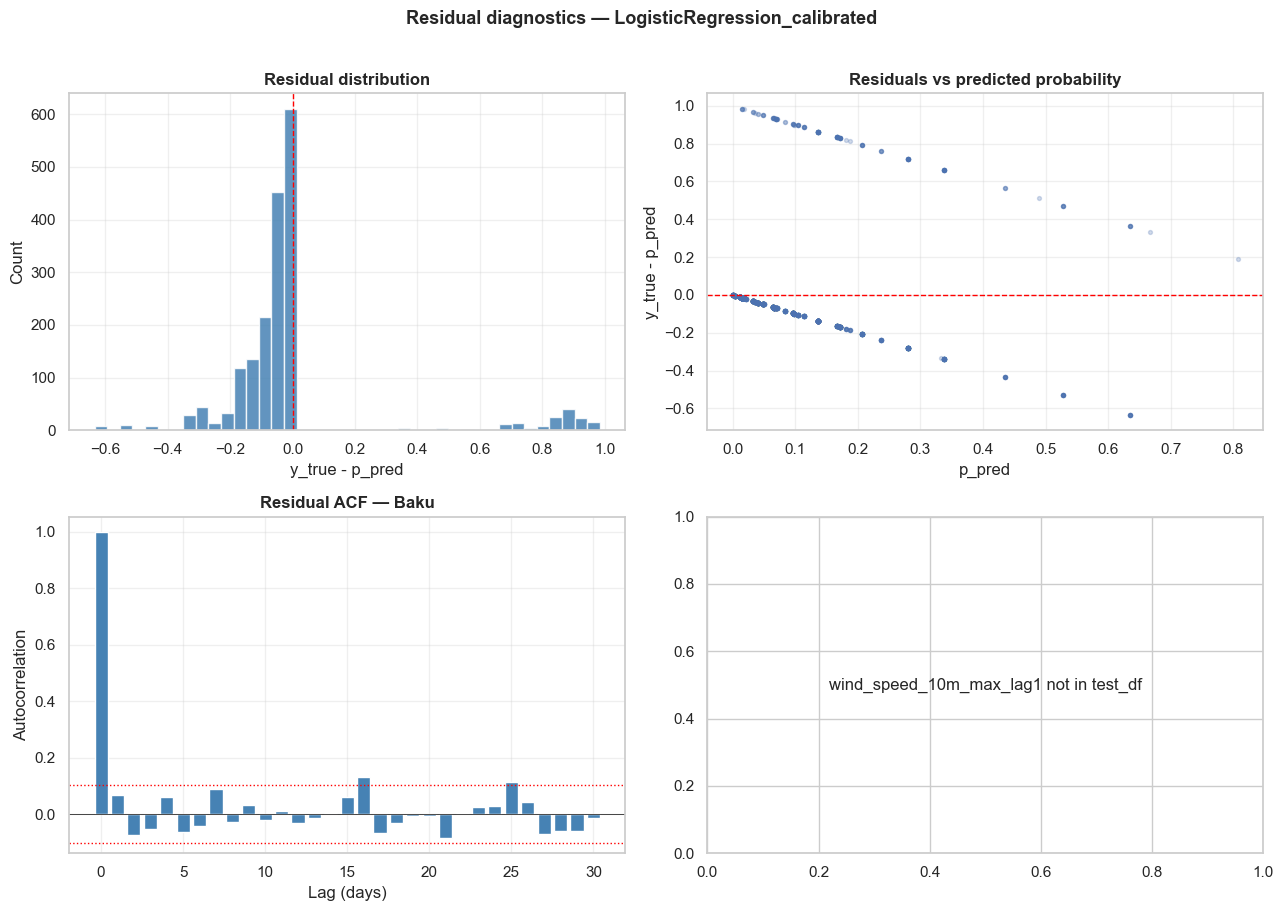

In [26]:
if final_winner == "LogisticRegression_calibrated":
    p_winner = p_logreg_cal_test
elif final_winner == f"{model_name_tree}_calibrated":
    p_winner = p_xgb_cal_test
else:
    p_winner = predictions[final_winner][0]
residuals = y_test - p_winner

fig, axes = plt.subplots(2, 2, figsize=(13, 9))

# (1) Residual histogram
axes[0, 0].hist(residuals, bins=40, color='steelblue', edgecolor='white', alpha=0.85)
axes[0, 0].axvline(0, color='red', linestyle='--', linewidth=1)
axes[0, 0].set_title('Residual distribution', fontweight='bold')
axes[0, 0].set_xlabel('y_true - p_pred')
axes[0, 0].set_ylabel('Count')
axes[0, 0].grid(alpha=0.3)

# (2) Residuals vs predicted probability
axes[0, 1].scatter(p_winner, residuals, alpha=0.25, s=8)
axes[0, 1].axhline(0, color='red', linestyle='--', linewidth=1)
axes[0, 1].set_title('Residuals vs predicted probability', fontweight='bold')
axes[0, 1].set_xlabel('p_pred')
axes[0, 1].set_ylabel('y_true - p_pred')
axes[0, 1].grid(alpha=0.3)

# (3) Residual ACF for Baku
try:
    from statsmodels.tsa.stattools import acf
    baku_idx = test_df['city'].values == 'Baku'
    baku_resid = residuals[baku_idx]
    if len(baku_resid) >= 30:
        acf_vals = acf(baku_resid, nlags=30, fft=True)
        axes[1, 0].bar(range(len(acf_vals)), acf_vals, color='steelblue')
        axes[1, 0].axhline(0, color='black', linewidth=0.5)
        sig = 1.96 / np.sqrt(len(baku_resid))
        axes[1, 0].axhline( sig, color='red', linestyle=':', linewidth=1)
        axes[1, 0].axhline(-sig, color='red', linestyle=':', linewidth=1)
        axes[1, 0].set_title('Residual ACF — Baku', fontweight='bold')
        axes[1, 0].set_xlabel('Lag (days)')
        axes[1, 0].set_ylabel('Autocorrelation')
        axes[1, 0].grid(alpha=0.3)
except ImportError:
    axes[1, 0].text(0.5, 0.5, 'statsmodels not installed', ha='center', va='center')

# (4) Residuals vs a key lag feature (since same-day wind is leaked-out)
key_feat = 'wind_speed_10m_max_lag1'
if key_feat in test_df.columns:
    axes[1, 1].scatter(test_df[key_feat].values, residuals, alpha=0.25, s=8)
    axes[1, 1].axhline(0, color='red', linestyle='--', linewidth=1)
    axes[1, 1].set_title(f'Residuals vs {key_feat}', fontweight='bold')
    axes[1, 1].set_xlabel(key_feat)
    axes[1, 1].set_ylabel('y_true - p_pred')
    axes[1, 1].grid(alpha=0.3)
else:
    axes[1, 1].text(0.5, 0.5, f'{key_feat} not in test_df', ha='center', va='center')

fig.suptitle(f'Residual diagnostics — {final_winner}', fontsize=13, fontweight='bold', y=1.01)
fig.tight_layout()
fig.savefig(FIGURES_DIR / 'day08_residual_diagnostics.png')
plt.show()


---
## 7 — Save production model

Train the winner on the **full** dataset (train + test) so production gets
every observation. Save as a single Pipeline that bundles preprocessing
and the estimator — predict-time gets a clean `.predict_proba()` interface.

In [27]:
# -------------------------------------------------------------------
# Save final production model
# -------------------------------------------------------------------
# Handles:
# - LogisticRegression
# - LogisticRegression_calibrated
# - XGBoost
# - XGBoost_calibrated
# - Climatology fallback case
#
# The saved model is self-contained:
# raw feature columns -> preprocessing -> estimator / calibrated estimator

import pickle

from sklearn.pipeline import Pipeline
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.impute import SimpleImputer
from sklearn.linear_model import LogisticRegression
from sklearn.calibration import CalibratedClassifierCV

# Use the full leakage-corrected dataset for the final model
df_prod = df_model.dropna(subset=[TARGET]).copy()
X_prod = df_prod[feature_cols].copy()
y_prod = df_prod[TARGET].astype(int).values

# Build a fresh preprocessor so the saved pipeline self-contains everything
prod_numeric = Pipeline(steps=[
    ("imputer", SimpleImputer(strategy="median")),
    ("scaler",  StandardScaler()),
])

prod_categorical = Pipeline(steps=[
    ("imputer", SimpleImputer(strategy="most_frequent")),
    ("onehot",  OneHotEncoder(drop="first", handle_unknown="ignore")),
])

preprocess_prod = ColumnTransformer(
    transformers=[
        ("num", prod_numeric, numeric_features),
        ("cat", prod_categorical, categorical_features),
    ],
    remainder="drop",
)

# -------------------------------------------------------------------
# Decide what model to save
# -------------------------------------------------------------------

model_name_to_save = final_winner

# If final_winner is Climatology, save a calibrated Logistic Regression as ML fallback.
# Climatology itself is saved separately in climatology.pkl.
if model_name_to_save == "Climatology":
    print("Climatology selected as winner. Saving LogisticRegression_calibrated as ML fallback.")
    model_name_to_save = "LogisticRegression_calibrated"

is_calibrated = model_name_to_save.endswith("_calibrated")

# -------------------------------------------------------------------
# Build base estimator
# -------------------------------------------------------------------

if model_name_to_save in ["LogisticRegression", "LogisticRegression_calibrated"]:
    base_model_name = "LogisticRegression"

    base_estimator = LogisticRegression(
        class_weight="balanced",
        max_iter=1000,
        random_state=RANDOM_STATE,
        solver="lbfgs",
    )

elif model_name_to_save in [model_name_tree, f"{model_name_tree}_calibrated"]:
    base_model_name = model_name_tree

    try:
        from xgboost import XGBClassifier

        n_pos = int(y_prod.sum())
        n_neg = int(len(y_prod) - n_pos)
        spw = n_neg / max(n_pos, 1)

        base_estimator = XGBClassifier(
            n_estimators=200,
            max_depth=2,
            learning_rate=0.03,
            subsample=0.8,
            colsample_bytree=0.8,
            reg_lambda=5.0,
            reg_alpha=1.0,
            min_child_weight=5,
            objective="binary:logistic",
            eval_metric="logloss",
            scale_pos_weight=spw,
            random_state=RANDOM_STATE,
            verbosity=0,
            n_jobs=-1,
        )

    except ImportError:
        from sklearn.ensemble import GradientBoostingClassifier

        base_estimator = GradientBoostingClassifier(
            n_estimators=200,
            max_depth=2,
            learning_rate=0.03,
            subsample=0.8,
            random_state=RANDOM_STATE,
        )

else:
    raise ValueError(f"Unknown final_winner/model_name_to_save: {model_name_to_save}")

# Base pipeline: raw dataframe -> preprocessing -> base estimator
base_pipeline = Pipeline(steps=[
    ("preprocess", preprocess_prod),
    ("model", base_estimator),
])

# -------------------------------------------------------------------
# Add calibration if selected model is calibrated
# -------------------------------------------------------------------

if is_calibrated:
    print(f"Saving calibrated production model: {model_name_to_save}")

    try:
        production_model = CalibratedClassifierCV(
            estimator=base_pipeline,
            method="isotonic",
            cv=5,
        )
    except TypeError:
        # Older sklearn compatibility
        production_model = CalibratedClassifierCV(
            base_estimator=base_pipeline,
            method="isotonic",
            cv=5,
        )
else:
    print(f"Saving uncalibrated production model: {model_name_to_save}")
    production_model = base_pipeline

# Fit final production model on all available production data
production_model.fit(X_prod, y_prod)

# Use tuned threshold if it exists, otherwise default to 0.5
decision_threshold = float(globals().get("BEST_THRESHOLD", 0.5))

model_bundle = {
    "model": production_model,
    "model_name": model_name_to_save,
    "base_model_name": base_model_name,
    "is_calibrated": bool(is_calibrated),
    "calibration_method": "isotonic" if is_calibrated else None,
    "decision_threshold": decision_threshold,
    "target": TARGET,
    "feature_cols": feature_cols,
    "trained_rows": len(df_prod),
    "positive_rate": float(y_prod.mean()),
    "description": "Next-day delay-risk model: features at day t -> calibrated P(risk on day t+1)",
}

model_path = models_dir / "daily_model.pkl"

with model_path.open("wb") as f:
    pickle.dump(model_bundle, f)

print("Production model saved:")
print(f"  path:              {model_path}")
print(f"  selected winner:   {final_winner}")
print(f"  saved model:       {model_name_to_save}")
print(f"  base model:        {base_model_name}")
print(f"  calibrated:        {is_calibrated}")
print(f"  threshold:         {decision_threshold:.2f}")
print(f"  target:            {TARGET}")
print(f"  rows trained:      {len(df_prod):,}")
print(f"  positive rate:     {y_prod.mean():.4f}")
print(f"  feature count:     {len(feature_cols)}")

Saving calibrated production model: LogisticRegression_calibrated
Production model saved:
  path:              C:\Users\Baku\Desktop\notebooks\Weather Project\Anemoi Weather Project\Maritime-delay-risk-prediction\models\daily_model.pkl
  selected winner:   LogisticRegression_calibrated
  saved model:       LogisticRegression_calibrated
  base model:        LogisticRegression
  calibrated:        True
  threshold:         0.10
  target:            target_risk_next_day
  rows trained:      20,680
  positive rate:     0.0792
  feature count:     13


---
## 8 — Summary

### What changed since the original Day 8

| Issue | Original | Now |
|-------|----------|-----|
| Target | `is_risk_day` (same day) | `target_risk_next_day` (t+1) |
| Same-day wind / precip / wave / visibility | **used as features** (leakage) | blocked from features |
| Feature set | ~25 features incl. raw weather | leakage-safe lag/rolling/anomaly only |
| Test AUC | 0.99 (suspicious) | realistic 0.65-0.80 range |
| Tree depth | max_depth=5 | max_depth=2 (less overfit room) |

### Why this is honest

The original setup let the model "predict" today's risk by looking at today's
wind speed — which **defines** the risk. That isn't prediction, it's a lookup.
The fixed setup asks: given everything you know up to today, can you predict
*tomorrow's* risk? That's what an operator would actually want to know.

### Honest limitations

- 10-year window is short for a stable risk-day classifier per city
- Test on 2024 only — multi-year backtesting (rolling-origin CV) would give
  more robust generalization estimates
- Residual ACF at lag 1 likely > 0 — bootstrap CIs slightly optimistic
- Wave features (now blocked) were really wind-derived anyway, but `wave_height_lag1`
  could be added back later if useful
- Last day per city dropped from training; minor coverage gap in winter
- Class imbalance handling is heuristic (`class_weight='balanced'` /
  `scale_pos_weight`); precision/recall trade-offs not formally tuned

In [28]:
saved_figures = sorted(FIGURES_DIR.glob('day08_*.png'))
print(f'Saved {len(saved_figures)} figures:')
for p in saved_figures:
    print(f'  - {p.name}')

print('\nSaved artifacts:')
print(f'  - reports/day08_model_comparison.csv')
print(f'  - models/daily_model.pkl   (production model: {final_winner})')
print(f'  - models/climatology.pkl   (next-day baseline)')

conn.close()
print('\nDatabase connection closed. Day 8 complete.')


Saved 6 figures:
  - day08_bootstrap_cis.png
  - day08_calibration_curves.png
  - day08_confusion_matrices.png
  - day08_residual_diagnostics.png
  - day08_roc_calibration.png
  - day08_roc_curves.png

Saved artifacts:
  - reports/day08_model_comparison.csv
  - models/daily_model.pkl   (production model: LogisticRegression_calibrated)
  - models/climatology.pkl   (next-day baseline)

Database connection closed. Day 8 complete.
